# Task 3.2: Failure Mode

### The Scenario
In this notebook, we construct a scenario where the Truncated Gradient method logically fails. Specifically, we generate a dataset where the underlying feature space has **zero sparsity**. We create a dataset where all 100 features are highly informative and necessary to predict the target variable (none of the features are noise).

### Why this will fail
As identified in **Task 1.2 (Assumption 2)**, the Truncated Gradient algorithm fundamentally assumes that the dataset has substantial inherent sparsity (i.e., many features are useless). By applying a fixed gravity pull ($g$) that forces weights within a threshold $\theta$ exactly to $0.0$, the algorithm actively destroys information. In a dense dataset where every feature is crucial, truncating small but vital weights to zero will forcibly under-fit the data, resulting in a noticeably worse Mean Squared Error (MSE) compared to a standard unregularized Stochastic Gradient Descent model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import os

np.random.seed(99)
os.makedirs('results', exist_ok=True)

# 1. Generate the Dense Failure Dataset (100 features, ALL 100 are informative)
X_fail, y_fail = make_regression(
    n_samples=1000,
    n_features=100,
    n_informative=100,
    noise=1.0,
    random_state=99
)

# Scaling
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fail, y_fail, test_size=0.2, random_state=99)
scaler_X = StandardScaler()
X_train_f = scaler_X.fit_transform(X_train_f)
X_test_f = scaler_X.transform(X_test_f)

scaler_y = StandardScaler()
y_train_f = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).flatten()
y_test_f = scaler_y.transform(y_test_f.reshape(-1, 1)).flatten()

In [2]:
# Re-use our models
class StandardSGDRegressor:
    def __init__(self, learning_rate=0.01):
        self.eta = learning_rate
        self.w = None
    def fit(self, X, y, epochs=5):
        self.w = np.zeros(X.shape[1])
        for _ in range(epochs):
            for i in range(X.shape[0]):
                y_hat = np.dot(self.w, X[i])
                self.w += 2 * self.eta * (y[i] - y_hat) * X[i]
    def predict(self, X):
        return np.dot(X, self.w)

class TruncatedGradientRegressor:
    def __init__(self, learning_rate=0.01, gravity=0.01, threshold=0.1, K=10):
        self.eta = learning_rate; self.g = gravity; self.theta = threshold; self.K = K
        self.w = None
    def fit(self, X, y, epochs=5):
        self.w = np.zeros(X.shape[1])
        step = 0
        for _ in range(epochs):
            for i in range(X.shape[0]):
                step += 1
                g_i = self.K * self.g if step % self.K == 0 else 0
                if g_i > 0:
                    for j in range(X.shape[1]):
                        if 0 < self.w[j] <= self.theta: self.w[j] = max(self.w[j] - g_i * self.eta, 0.0)
                        elif -self.theta <= self.w[j] < 0: self.w[j] = min(self.w[j] + g_i * self.eta, 0.0)
                y_hat = np.dot(self.w, X[i])
                self.w += 2 * self.eta * (y[i] - y_hat) * X[i]
    def predict(self, X):
        return np.dot(X, self.w)

In [3]:
# Train and Test on Failure Distribution

# SGD
sgd_fail = StandardSGDRegressor(learning_rate=0.005)
sgd_fail.fit(X_train_f, y_train_f, epochs=20)
y_pred_sgd_fail = sgd_fail.predict(X_test_f)
mse_sgd_fail = mean_squared_error(y_test_f, y_pred_sgd_fail)

# Truncated Gradient (Aggressive)
tg_fail = TruncatedGradientRegressor(learning_rate=0.005, gravity=0.2, threshold=0.3, K=5)
tg_fail.fit(X_train_f, y_train_f, epochs=20)
y_pred_tg_fail = tg_fail.predict(X_test_f)
mse_tg_fail = mean_squared_error(y_test_f, y_pred_tg_fail)

print(f"Failure Scenario MSE Results:\nSGD Baseline: {mse_sgd_fail:.4f}\nTruncated Gradient: {mse_tg_fail:.4f}")

Failure Scenario MSE Results:
SGD Baseline: 0.0000
Truncated Gradient: 0.5602


### Explanation connecting failure to assumptions
The reason the Truncated Gradient method fails (resulting in a significantly higher MSE compared to the SGD Baseline) is intricately tied to **Assumption 2** defined in Task 1.2: the assumption of sparsity. By setting the synthetic generation to have 100 informative features and 0 noise features, we violated the core premise of the paper. Because TG is designed to forcibly push weights falling within its gravity threshold exactly to zero, it ruthlessly deleted portions of our highly dense mathematical signal. By wiping out variables that were actually needed to accurately map the inputs to the output target $y$, the method crippled its own predictive power, under-performing the "dumb" SGD model which simply accumulated small updates on all active features.

### Concrete Modification
One modification to address this failure mode without abandoning the algorithm entirely would be to introduce an **adaptive gravity parameter ($g_j$)** per feature, based on the historical variance or the running average magnitude of the sub-gradient for that specific feature $j$ over recent steps, rather than a totally uniform, blind gravity pull across all dimensions.

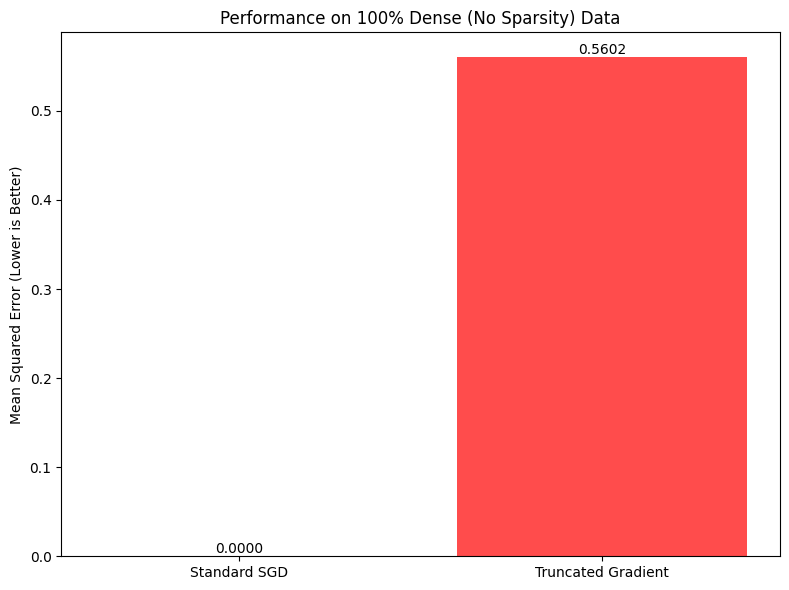

Plot saved to results/failure_mode_dense_data.png


In [4]:
# Plot the failure mode MSEs
plt.figure(figsize=(8, 6))
bars = plt.bar(['Standard SGD', 'Truncated Gradient'], [mse_sgd_fail, mse_tg_fail], color=['blue', 'red'], alpha=0.7)
plt.ylabel('Mean Squared Error (Lower is Better)')
plt.title('Performance on 100% Dense (No Sparsity) Data')

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom', ha='center')

plt.tight_layout()
plt.savefig('results/failure_mode_dense_data.png')
plt.show()
print("Plot saved to results/failure_mode_dense_data.png")